In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

df = pd.read_csv('messy_customer_churn.csv')
print(df.shape)
df.dtypes

(431, 12)


Unnamed: 0               int64
customer_id                str
age                    float64
gender                     str
tenure_months          float64
contract_type              str
payment_method             str
monthly_charges            str
total_charges              str
num_support_tickets    float64
signup_date                str
has_churned                str
dtype: object

In [2]:
df

,Unnamed: 0,customer_id,age,gender,tenure_months,contract_type,payment_method,monthly_charges,total_charges,num_support_tickets,signup_date,has_churned
0,0,CUST00121,43.0,F,70.0,Month-to-month,Credit card,$59.74,4178.01,0.0,2019-09-17,false
1,1,CUST00178,27.0,Female,47.0,two year,Bank transfer,112.67,"$5,319.53",2.0,2022-03-13,Yes
2,2,CUST00222,43.0,Female,0.0,One year,Credit card,NaN,0.0,1.0,2021-11-24,true
3,3,CUST00378,60.0,Male,44.0,One year,Electronic check,$87.66,3832.18,3.0,10/25/2022,true
4,4,CUST00279,21.0,Female,50.0,Month-to-month,Electronic check,54.93,NaN,1.0,2022-05-24,No
...,...,...,...,...,...,...,...,...,...,...,...,...
426,426,CUST00212,58.0,Unknown,50.0,Month-to-month,Electronic check,$57.82,"$2,900.78",0.0,2019-10-17,N
427,427,CUST00068,39.0,Unknown,6.0,Month-to-month,Bank transfer,94.5,$557.26,0.0,11/15/2020,Yes
428,428,CUST00026,54.0,F,3.0,two year,Bank transfer,109.28,$336.61,0.0,18-Aug-2022,1
429,429,CUST00197,37.0,NaN,70.0,Month-to-month,Bank transfer,98.71,6934.6,2.0,08/17/2020,N


In [3]:
print("Shape:", df.shape)

df.head()

Shape: (431, 12)


,Unnamed: 0,customer_id,age,gender,tenure_months,contract_type,payment_method,monthly_charges,total_charges,num_support_tickets,signup_date,has_churned
0,0,CUST00121,43.0,F,70.0,Month-to-month,Credit card,$59.74,4178.01,0.0,2019-09-17,false
1,1,CUST00178,27.0,Female,47.0,two year,Bank transfer,112.67,"$5,319.53",2.0,2022-03-13,Yes
2,2,CUST00222,43.0,Female,0.0,One year,Credit card,NaN,0.0,1.0,2021-11-24,true
3,3,CUST00378,60.0,Male,44.0,One year,Electronic check,$87.66,3832.18,3.0,10/25/2022,true
4,4,CUST00279,21.0,Female,50.0,Month-to-month,Electronic check,54.93,NaN,1.0,2022-05-24,No


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           431 non-null    int64  
 1   customer_id          429 non-null    str    
 2   age                  419 non-null    float64
 3   gender               407 non-null    str    
 4   tenure_months        429 non-null    float64
 5   contract_type        429 non-null    str    
 6   payment_method       429 non-null    str    
 7   monthly_charges      405 non-null    str    
 8   total_charges        391 non-null    str    
 9   num_support_tickets  421 non-null    float64
 10  signup_date          405 non-null    str    
 11  has_churned          429 non-null    str    
dtypes: float64(3), int64(1), str(8)
memory usage: 40.5 KB


In [5]:
df.describe(include="all").T   # the T means transpose which convert the rows into columns and columns into rows 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,431.0,NaN,NaN,NaN,215.0,124.563237,0.0,107.5,215.0,322.5,430.0
customer_id,429,420,CUST00214,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,419.0,NaN,NaN,NaN,47.298329,23.231089,0.0,32.0,45.0,60.5,199.0
gender,407,11,F,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,429.0,NaN,NaN,NaN,43.496503,95.170595,-3.0,17.0,35.0,53.0,999.0
contract_type,429,12,Month-to-month,145,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,429,4,Mailed check,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_charges,405,388,15.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_charges,391,379,0.0,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_support_tickets,421.0,NaN,NaN,NaN,1.178147,1.081928,0.0,0.0,1.0,2.0,6.0


In [6]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().mean()*100).round(2)
})

missing.sort_values("Missing Values", ascending=False)   # it finds and counts the mising values and caluates the missing value fraction and convert it into percentage

,Missing Values,Percentage
total_charges,40,9.28
monthly_charges,26,6.03
signup_date,26,6.03
gender,24,5.57
age,12,2.78
num_support_tickets,10,2.32
payment_method,2,0.46
customer_id,2,0.46
tenure_months,2,0.46
contract_type,2,0.46


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
df["customer_id"].duplicated().sum()

np.int64(10)

In [9]:
# This code iterates through all categorical columns and displays the count of each unique value, including missing values, for data exploration.
for col in df.select_dtypes(include="object"):
    print("="*50)
    print(col)
    print(df[col].value_counts(dropna=False))

customer_id
customer_id
CUST00214    2
CUST00335    2
CUST00379    2
CUST00166    2
NaN          2
            ..
CUST00212    1
CUST00068    1
CUST00026    1
CUST00197    1
CUST00176    1
Name: count, Length: 421, dtype: int64
gender
gender
F           49
male        44
Male        41
FEMALE      41
female      41
 Female     39
Female      38
 Male       38
MALE        35
M           28
NaN         24
Unknown     13
Name: count, dtype: int64
contract_type
contract_type
Month-to-month      145
One year             62
Two year             51
month-to-month       50
MONTH-TO-MONTH       34
two year             18
ONE YEAR             18
TWO YEAR             13
 Month-to-month      12
 One year             9
one year              9
 Two year             8
NaN                   2
Name: count, dtype: int64
payment_method
payment_method
Mailed check        122
Credit card         111
Bank transfer       103
Electronic check     93
NaN                   2
Name: count, dtype: int64
monthly_ch

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11344\280002454.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


In [10]:
df.describe()

,Unnamed: 0,age,tenure_months,num_support_tickets
count,431.000000,419.000000,429.000000,421.000000
mean,215.000000,47.298329,43.496503,1.178147
std,124.563237,23.231089,95.170595,1.081928
min,0.000000,0.000000,-3.000000,0.000000
25%,107.500000,32.000000,17.000000,0.000000
50%,215.000000,45.000000,35.000000,1.000000
75%,322.500000,60.500000,53.000000,2.000000
max,430.000000,199.000000,999.000000,6.000000


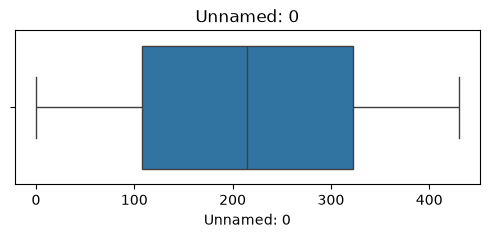

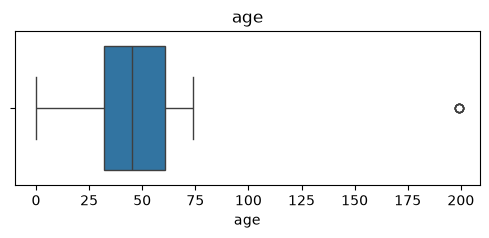

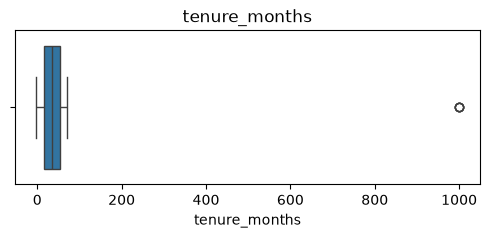

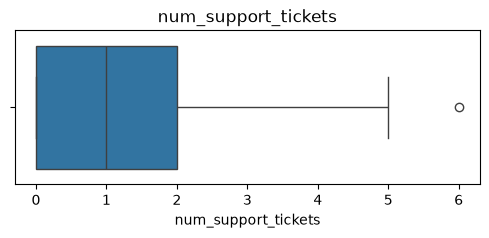

In [11]:
# This code identifies all numeric columns in the dataset and generates a separate box plot for each one.
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

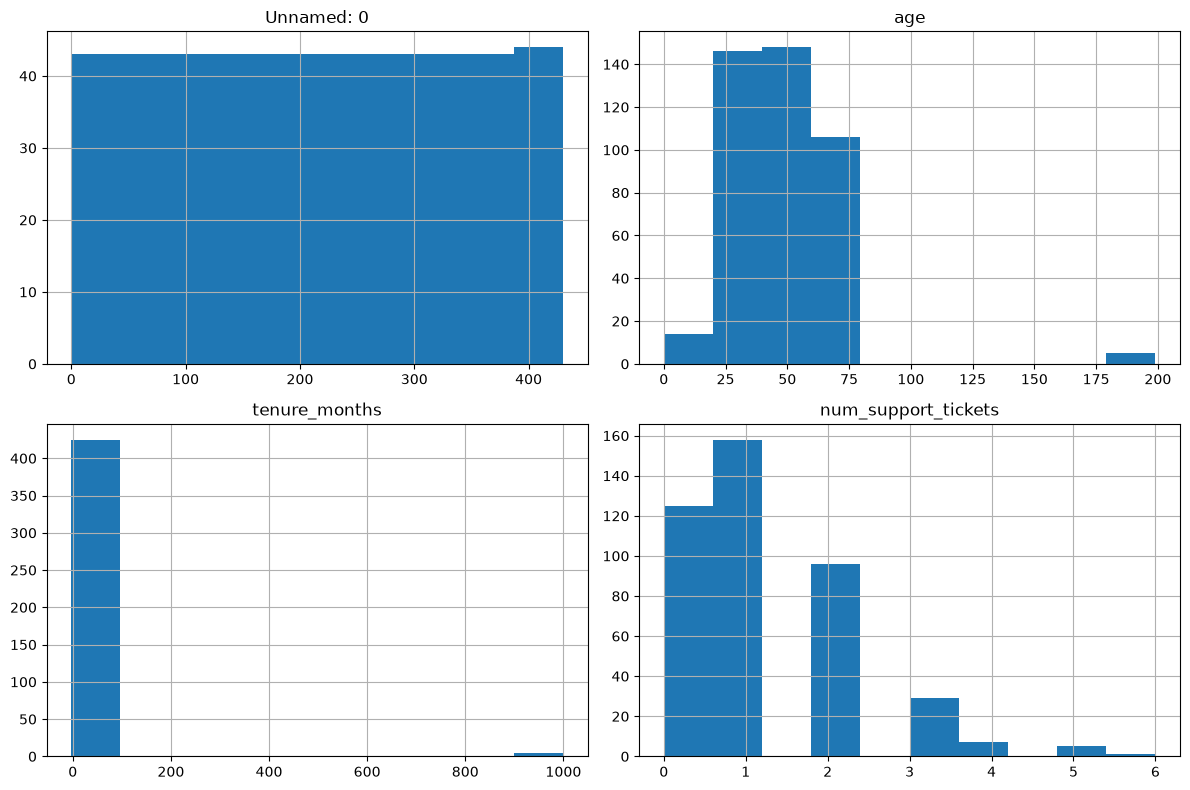

In [12]:
df.hist(figsize=(12,8))
plt.tight_layout()

In [13]:
# This code loops through all categorical columns in the dataset. For each column, it prints the column name, the number of unique values including missing values, and the frequency of each category
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print("=" * 60)
    print(f"Column: {col}")
    print(f"Unique Values: {df[col].nunique(dropna=False)}")
    print(df[col].value_counts(dropna=False))
    print()

Column: customer_id
Unique Values: 421
customer_id
CUST00214    2
CUST00335    2
CUST00379    2
CUST00166    2
NaN          2
            ..
CUST00212    1
CUST00068    1
CUST00026    1
CUST00197    1
CUST00176    1
Name: count, Length: 421, dtype: int64

Column: gender
Unique Values: 12
gender
F           49
male        44
Male        41
FEMALE      41
female      41
 Female     39
Female      38
 Male       38
MALE        35
M           28
NaN         24
Unknown     13
Name: count, dtype: int64

Column: contract_type
Unique Values: 13
contract_type
Month-to-month      145
One year             62
Two year             51
month-to-month       50
MONTH-TO-MONTH       34
two year             18
ONE YEAR             18
TWO YEAR             13
 Month-to-month      12
 One year             9
one year              9
 Two year             8
NaN                   2
Name: count, dtype: int64

Column: payment_method
Unique Values: 5
payment_method
Mailed check        122
Credit card         111
B

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11344\84129722.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [14]:
print(df.dtypes)

Unnamed: 0               int64
customer_id                str
age                    float64
gender                     str
tenure_months          float64
contract_type              str
payment_method             str
monthly_charges            str
total_charges              str
num_support_tickets    float64
signup_date                str
has_churned                str
dtype: object


In [15]:
df["monthly_charges"].head(20)

0     $59.74
1     112.67
2        NaN
3     $87.66
4      54.93
5      58.99
6     120.52
7     $29.78
8       49.6
9      48.45
10    $69.94
11     104.8
12    $51.38
13    105.25
14     65.63
15    $54.65
16      67.8
17     133.3
18    $81.75
19      84.6
Name: monthly_charges, dtype: str

In [16]:
df["total_charges"].head(20)

0       4178.01
1     $5,319.53
2           0.0
3       3832.18
4           NaN
5           NaN
6        1688.4
7     $1,665.94
8        782.19
9       3441.05
10      3903.04
11      2950.81
12       421.57
13          NaN
14          NaN
15    $1,366.32
16        87.85
17      2125.35
18    $2,847.21
19      1784.88
Name: total_charges, dtype: str

In [17]:
df["signup_date"].head(20)

0      2019-09-17
1      2022-03-13
2      2021-11-24
3      10/25/2022
4      2022-05-24
5      2020-07-10
6      2022-04-28
7      09/27/2022
8             NaN
9     26-Jun-2019
10    12-Nov-2023
11    27-Feb-2020
12     12/26/2019
13     2019-10-31
14     2020-04-04
15     2021-02-27
16            NaN
17            NaN
18     2019-08-14
19     02/13/2019
Name: signup_date, dtype: str

In [18]:
duplicate_customers = df[df["customer_id"].duplicated(keep=False)]
duplicate_customers.sort_values("customer_id")

,Unnamed: 0,customer_id,age,gender,tenure_months,contract_type,payment_method,monthly_charges,total_charges,num_support_tickets,signup_date,has_churned
163,163,CUST00005,42.0,female,17.0,Month-to-month,Credit card,96.24,1627.28,2.0,07/15/2019,0
363,363,CUST00005,42.0,female,17.0,Month-to-month,Credit card,96.24,1627.28,2.0,07/15/2019,0
358,358,CUST00018,25.0,Female,55.0,Two year,Bank transfer,$85.54,NaN,3.0,23-Aug-2022,No
302,302,CUST00018,25.0,Female,55.0,Two year,Bank transfer,$85.54,NaN,3.0,23-Aug-2022,No
73,73,CUST00166,64.0,MALE,58.0,MONTH-TO-MONTH,Bank transfer,$100.80,5853.29,0.0,NaN,0
286,286,CUST00166,64.0,MALE,58.0,MONTH-TO-MONTH,Bank transfer,$100.80,5853.29,0.0,NaN,0
118,118,CUST00180,46.0,NaN,68.0,Month-to-month,Credit card,90.12,6116.88,5.0,10/09/2023,N
250,250,CUST00180,46.0,NaN,68.0,Month-to-month,Credit card,90.12,6116.88,5.0,10/09/2023,N
6,6,CUST00214,43.0,male,14.0,month-to-month,Credit card,120.52,1688.4,0.0,2022-04-28,1
200,200,CUST00214,43.0,male,14.0,month-to-month,Credit card,120.52,1688.4,0.0,2022-04-28,1


In [19]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [20]:
df.columns

Index(['customer_id', 'age', 'gender', 'tenure_months', 'contract_type',
       'payment_method', 'monthly_charges', 'total_charges',
       'num_support_tickets', 'signup_date', 'has_churned'],
      dtype='str')

In [21]:
# i used this to standardize the text columns to ensure every value is treated as string
object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
    df[col] = df[col].astype(str).str.strip()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11344\417232231.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include="object").columns


In [22]:
for col in object_cols:
    print(col)
    print(df[col].head())

customer_id
0    CUST00121
1    CUST00178
2    CUST00222
3    CUST00378
4    CUST00279
Name: customer_id, dtype: str
gender
0         F
1    Female
2    Female
3      Male
4    Female
Name: gender, dtype: str
contract_type
0    Month-to-month
1          two year
2          One year
3          One year
4    Month-to-month
Name: contract_type, dtype: str
payment_method
0         Credit card
1       Bank transfer
2         Credit card
3    Electronic check
4    Electronic check
Name: payment_method, dtype: str
monthly_charges
0    $59.74
1    112.67
2       NaN
3    $87.66
4     54.93
Name: monthly_charges, dtype: str
total_charges
0      4178.01
1    $5,319.53
2          0.0
3      3832.18
4          NaN
Name: total_charges, dtype: str
signup_date
0    2019-09-17
1    2022-03-13
2    2021-11-24
3    10/25/2022
4    2022-05-24
Name: signup_date, dtype: str
has_churned
0    false
1      Yes
2     true
3     true
4       No
Name: has_churned, dtype: str


In [23]:
categorical_cols = [
    "gender",
    "contract_type",
    "payment_method",
    "has_churned"
]

for col in categorical_cols:
    df[col] = df[col].str.lower()

In [24]:
for col in categorical_cols:
    print("="*40) # Prints a separator line.
    print(col)
    print(df[col].value_counts(dropna=False))

gender
gender
female     159
male       158
f           49
m           28
NaN         24
unknown     13
Name: count, dtype: int64
contract_type
contract_type
month-to-month    241
one year           98
two year           90
NaN                 2
Name: count, dtype: int64
payment_method
payment_method
mailed check        122
credit card         111
bank transfer       103
electronic check     93
NaN                   2
Name: count, dtype: int64
has_churned
has_churned
no       83
0        79
false    74
n        74
y        34
true     31
yes      28
1        26
NaN       2
Name: count, dtype: int64


In [25]:
df["monthly_charges"].sample(15)

77      $79.73
333     $70.13
315      73.09
36       57.16
208      27.43
68       68.13
50         NaN
54      $66.95
363      96.24
352      49.31
139      88.74
258     $45.05
310    $117.33
384        NaN
26       107.0
Name: monthly_charges, dtype: str

In [26]:
df["total_charges"].sample(15)

153    $5,640.71
350         93.8
341      $382.49
317      2684.52
26     $6,533.14
339      $289.13
3        3832.18
363      1627.28
278      4098.52
314      4611.18
146      3546.81
418      5194.67
209       186.33
417      3741.95
248          NaN
Name: total_charges, dtype: str

In [27]:
df["monthly_charges"].sample(15)

100    135.09
195       NaN
164    $95.22
178     85.78
8        49.6
46      47.81
207     71.69
119       NaN
220     95.98
217     98.51
330    $52.52
148     94.89
231     37.17
324    $72.97
254       NaN
Name: monthly_charges, dtype: str

In [28]:
df["total_charges"].sample(15)

323    $4,003.66
286      5853.29
391    $2,576.03
49        468.68
158       556.82
346      2664.88
169      3072.27
240      4958.26
367    $2,187.52
324      1750.52
168          0.0
306      1280.37
2            0.0
34     $3,999.22
155    $2,870.33
Name: total_charges, dtype: str

In [29]:
df["monthly_charges"] = (
    df["monthly_charges"]
      .str.replace("$", "", regex=False) # regex = regular expression
)

df["monthly_charges"] = pd.to_numeric(  # Converts the cleaned string values into numeric data types (int or float)
    df["monthly_charges"],
    errors="coerce"
)

In [30]:
df["monthly_charges"].dtype

dtype('float64')

In [31]:
df["total_charges"] = (
    df["total_charges"]
      .str.replace("$", "", regex=False)
      .str.replace(",", "", regex=False)
)

df["total_charges"] = pd.to_numeric(
    df["total_charges"],
    errors="coerce"
)

In [32]:
df["total_charges"].dtype

dtype('float64')

In [33]:
df.isnull().sum()

customer_id             2
age                    12
gender                 24
tenure_months           2
contract_type           2
payment_method          2
monthly_charges        26
total_charges          40
num_support_tickets    10
signup_date            26
has_churned             2
dtype: int64

In [34]:
df["signup_date"].sample(20)

40      06/18/2019
187     2019-10-04
354     2022-09-08
417    19-Jan-2022
32     07-Jul-2020
300     2021-02-18
223     06/08/2021
262     01/03/2022
280     07/02/2023
378     2023-01-07
299            NaN
68      2022-03-28
198     2021-12-05
54      2023-04-13
41      01/28/2020
236    07-May-2022
49     20-May-2020
399    07-Mar-2022
368            NaN
75      03/29/2023
Name: signup_date, dtype: str

In [35]:
df["signup_date"] = pd.to_datetime(
    df["signup_date"],
    format="mixed",
    errors="coerce"
)

In [36]:
df["signup_date"] = pd.to_datetime(
    df["signup_date"],
    errors="coerce"
)

In [37]:
df["signup_date"].head()


0   2019-09-17
1   2022-03-13
2   2021-11-24
3   2022-10-25
4   2022-05-24
Name: signup_date, dtype: datetime64[us]

In [38]:
df["signup_date"].dtype      # op: It means the signup_date column is stored as a datetime data type in NumPy.

dtype('<M8[us]')

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          429 non-null    str           
 1   age                  419 non-null    float64       
 2   gender               407 non-null    str           
 3   tenure_months        429 non-null    float64       
 4   contract_type        429 non-null    str           
 5   payment_method       429 non-null    str           
 6   monthly_charges      405 non-null    float64       
 7   total_charges        391 non-null    float64       
 8   num_support_tickets  421 non-null    float64       
 9   signup_date          405 non-null    datetime64[us]
 10  has_churned          429 non-null    str           
dtypes: datetime64[us](1), float64(5), str(5)
memory usage: 37.2 KB


In [40]:
df.isnull().sum()

customer_id             2
age                    12
gender                 24
tenure_months           2
contract_type           2
payment_method          2
monthly_charges        26
total_charges          40
num_support_tickets    10
signup_date            26
has_churned             2
dtype: int64

In [41]:
df["age"] = df["age"].fillna(df["age"].median())           # Replaces all missing (NaN) values with that median.

In [42]:
df["tenure_months"] = df["tenure_months"].fillna(df["tenure_months"].median())

In [43]:
df["num_support_tickets"] = df["num_support_tickets"].fillna(
    df["num_support_tickets"].median()
)

In [44]:
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])   # Fills all missing (NaN) values in the gender column with the most frequently occurring gender (mode)

In [45]:
df["contract_type"] = df["contract_type"].fillna(
    df["contract_type"].mode()[0]
)

In [46]:
df["payment_method"] = df["payment_method"].fillna(
    df["payment_method"].mode()[0]
)

In [47]:
df["monthly_charges"] = df["monthly_charges"].fillna(
    df["monthly_charges"].median()
)

In [48]:
df["total_charges"] = df["total_charges"].fillna(
    df["total_charges"].median()
)

In [49]:
median_date = df["signup_date"].dropna().sort_values().iloc[len(df["signup_date"].dropna())//2]

df["signup_date"] = df["signup_date"].fillna(median_date)

In [50]:
# This code is used to identify missing customer IDs and replace them with unique placeholder IDs.
mask = df["customer_id"].isna()  # isna() is a Pandas function that checks if a value is missing (NaN or NaT).

df.loc[mask, "customer_id"] = [
    f"UNKNOWN_{i}" for i in range(mask.sum())
]

In [51]:
df = df.dropna(subset=["has_churned"])

In [52]:
df.isnull().sum()

customer_id            0
age                    0
gender                 0
tenure_months          0
contract_type          0
payment_method         0
monthly_charges        0
total_charges          0
num_support_tickets    0
signup_date            0
has_churned            0
dtype: int64

In [53]:
import numpy as np

In [54]:
df.loc[(df["age"] < 18) | (df["age"] > 100), "age"] = np.nan  # This line checks every value in the age column.If the age is less than 18 or greater than 100 it replaces them with NaN values

df["age"] = df["age"].fillna(df["age"].median())

In [55]:
df.loc[
    (df["tenure_months"] < 0) |
    (df["tenure_months"] > 120),
    "tenure_months"
] = np.nan

df["tenure_months"] = df["tenure_months"].fillna(
    df["tenure_months"].median()
)

In [56]:
df.describe()

,age,tenure_months,monthly_charges,total_charges,num_support_tickets,signup_date
count,429.000000,429.000000,429.000000,429.000000,429.000000,429
mean,45.554779,34.590909,70.599394,2380.607925,1.174825,2021-06-07 18:57:54.125874
min,18.000000,0.000000,15.000000,0.000000,0.000000,2019-01-02 00:00:00
25%,33.000000,17.000000,55.350000,1082.140000,0.000000,2020-04-04 00:00:00
50%,45.000000,34.500000,69.500000,2125.990000,1.000000,2021-06-08 00:00:00
75%,59.000000,53.000000,87.280000,3302.410000,2.000000,2022-07-13 00:00:00
max,74.000000,71.000000,139.190000,8917.310000,6.000000,2023-12-04 00:00:00
std,15.816113,21.006032,24.324267,1629.334283,1.072041,NaN


In [57]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 9


In [58]:
df = df.drop_duplicates()

In [59]:
df["customer_id"].duplicated().sum()

np.int64(0)

In [60]:
duplicates = df[df["customer_id"].duplicated(keep=False)]  # This code is used to find all duplicate customer IDs and display them together in sorted order.
duplicates.sort_values("customer_id")

,customer_id,age,gender,tenure_months,contract_type,payment_method,monthly_charges,total_charges,num_support_tickets,signup_date,has_churned


In [61]:
df = df.drop_duplicates(subset="customer_id", keep="first")

In [62]:
# this is Feature Engineering part
# Feature 1 – Average Charge Per Month
df["avg_charge_per_month"] = (
    df["total_charges"] / df["tenure_months"].replace(0, 1)
)

In [63]:
# Feature 2 – Tenure Group
df["tenure_group"] = pd.cut(
    df["tenure_months"],
    bins=[0,12,24,48,120],
    labels=["New","1-2 Years","2-4 Years","4+ Years"]
)

In [64]:
# Feature 3 – High Support Ticket Flag
df["high_support"] = (
    df["num_support_tickets"] >= 3
).astype(int)

In [65]:
# Feature 4 – Senior Citizen
df["is_senior"] = (
    df["age"] >= 60
).astype(int)

In [83]:
df.to_csv("clean_customer_churn.csv", index=False)


In [67]:
import os

os.makedirs("output", exist_ok=True)
df.to_csv("output/clean_customer_churn.csv", index=False)


In [68]:
import os

print(os.getcwd())

d:\day2_data_preprocessing


In [69]:
df["has_churned"] = (
    df["has_churned"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["has_churned"] = df["has_churned"].replace({
    "true": "Yes",
    "1": "Yes",
    "y": "Yes",
    "yes": "Yes",

    "false": "No",
    "0": "No",
    "n": "No",
    "no": "No"
})

In [78]:
import os

os.makedirs("output", exist_ok=True)
df.to_csv("output/clean_customer_churn_v2.csv", index=False)


In [71]:
# Remove spaces and convert to lowercase
df["gender"] = df["gender"].astype(str).str.strip().str.lower()

# Replace inconsistent values
df["gender"] = df["gender"].replace({
    "m": "male",
    "f": "female",
    "unknown": np.nan
})

# Fill missing values (including 'unknown') with the most frequent gender
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])

In [76]:
print(df["gender"].value_counts(dropna=False))

gender
female    237
male      183
Name: count, dtype: int64


In [77]:
print(df["gender"].unique())

<StringArray>
['female', 'male']
Length: 2, dtype: str


DAY 3 TASK


In [124]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [125]:
df = pd.read_csv("clean_customer_churn.csv")


In [127]:
df.head()

df.info()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           420 non-null    str    
 1   age                   420 non-null    float64
 2   gender                420 non-null    str    
 3   tenure_months         420 non-null    float64
 4   contract_type         420 non-null    str    
 5   payment_method        420 non-null    str    
 6   monthly_charges       420 non-null    float64
 7   total_charges         420 non-null    float64
 8   num_support_tickets   420 non-null    float64
 9   signup_date           420 non-null    str    
 10  has_churned           420 non-null    str    
 11  avg_charge_per_month  420 non-null    float64
 12  tenure_group          412 non-null    str    
 13  high_support          420 non-null    int64  
 14  is_senior             420 non-null    int64  
dtypes: float64(6), int64(2), str(7)
me

customer_id             0
age                     0
gender                  0
tenure_months           0
contract_type           0
payment_method          0
monthly_charges         0
total_charges           0
num_support_tickets     0
signup_date             0
has_churned             0
avg_charge_per_month    0
tenure_group            8
high_support            0
is_senior               0
dtype: int64

In [128]:
label_encoder = LabelEncoder()

categorical_columns = [
    "gender",
    "contract_type",
    "payment_method",
    "tenure_group",
    "has_churned"
]

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

In [105]:
df = df.drop(columns=["customer_id"])

In [129]:
X = df.drop("has_churned", axis=1)

y = df["has_churned"]

In [131]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [108]:
print(X.dtypes)

age                     float64
gender                    int64
tenure_months           float64
contract_type             int64
payment_method            int64
monthly_charges         float64
total_charges           float64
num_support_tickets     float64
signup_date                 str
avg_charge_per_month    float64
tenure_group              int64
high_support              int64
is_senior                 int64
dtype: object


In [109]:
print(df.columns.tolist())

['age', 'gender', 'tenure_months', 'contract_type', 'payment_method', 'monthly_charges', 'total_charges', 'num_support_tickets', 'signup_date', 'has_churned', 'avg_charge_per_month', 'tenure_group', 'high_support', 'is_senior']


In [110]:
print(X.dtypes)

age                     float64
gender                    int64
tenure_months           float64
contract_type             int64
payment_method            int64
monthly_charges         float64
total_charges           float64
num_support_tickets     float64
signup_date                 str
avg_charge_per_month    float64
tenure_group              int64
high_support              int64
is_senior                 int64
dtype: object


In [132]:
df["signup_date"] = pd.to_datetime(df["signup_date"])

In [133]:
print(df["signup_date"].dtype)

datetime64[us]


In [134]:
# 1. Convert 'signup_date' to datetime format
df['signup_date'] = pd.to_datetime(df['signup_date'])

# 2. Extract year, month, and day into new columns
df['signup_year'] = df['signup_date'].dt.year
df['signup_month'] = df['signup_date'].dt.month
df['signup_day'] = df['signup_date'].dt.day

# 3. Now display the extracted date columns
df[["signup_date", "signup_year", "signup_month", "signup_day"]].head()


,signup_date,signup_year,signup_month,signup_day
0,2019-09-17,2019,9,17
1,2022-03-13,2022,3,13
2,2021-11-24,2021,11,24
3,2022-10-25,2022,10,25
4,2022-05-24,2022,5,24


In [135]:
df_model = df.drop(columns=["signup_date"])

In [136]:
X = df_model.drop("has_churned", axis=1)
y = df_model["has_churned"]

In [138]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [139]:
# Create a new dataframe for modeling
df_model = df.drop(columns=["signup_date"])

# Features
X = df_model.drop("has_churned", axis=1)

# Target
y = df_model["has_churned"]

In [140]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [143]:
X = df.drop(columns=['customer_id', 'has_churned'])  # Adjust 'has_churned' if your target column name is different
y = df['has_churned']

In [144]:
# 2. Encode categorical string columns (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)


In [145]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [147]:
print(X_train.dtypes)

age                            float64
gender                           int64
tenure_months                  float64
contract_type                    int64
payment_method                   int64
monthly_charges                float64
total_charges                  float64
num_support_tickets            float64
signup_date             datetime64[us]
avg_charge_per_month           float64
tenure_group                     int64
high_support                     int64
is_senior                        int64
signup_year                      int32
signup_month                     int32
signup_day                       int32
dtype: object


In [148]:
X_train = X_train.drop(columns=["signup_date"])
X_test = X_test.drop(columns=["signup_date"])

In [151]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [150]:
print(X_train.dtypes)

age                     float64
gender                    int64
tenure_months           float64
contract_type             int64
payment_method            int64
monthly_charges         float64
total_charges           float64
num_support_tickets     float64
avg_charge_per_month    float64
tenure_group              int64
high_support              int64
is_senior                 int64
signup_year               int32
signup_month              int32
signup_day                int32
dtype: object


In [152]:
print(X_train.shape)
print(X_train.isnull().sum())

(336, 15)
age                     0
gender                  0
tenure_months           0
contract_type           0
payment_method          0
monthly_charges         0
total_charges           0
num_support_tickets     0
avg_charge_per_month    0
tenure_group            0
high_support            0
is_senior               0
signup_year             0
signup_month            0
signup_day              0
dtype: int64


In [153]:
print(X_train.isnull().sum().sum())

0


In [154]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [155]:
y_pred_log = log_model.predict(X_test_scaled)

In [156]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("ROC-AUC  :", roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:, 1]))

Accuracy : 0.7738095238095238
Precision: 0.6923076923076923
Recall   : 0.375
F1 Score : 0.4864864864864865
ROC-AUC  : 0.7388888888888888


In [157]:
# Train Model 2 – Random Forest
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# I chose 100 trees because it's a common starting point that provides stable performance without making training too slow.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)  

In [159]:
#Unlike Logistic Regression, Random Forest does not require feature scaling.
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [160]:
y_pred_rf = rf_model.predict(X_test)

In [161]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(
    y_test,
    rf_model.predict_proba(X_test)[:, 1]
))

Accuracy : 0.7023809523809523
Precision: 0.45454545454545453
Recall   : 0.20833333333333334
F1 Score : 0.2857142857142857
ROC-AUC  : 0.6774305555555556


In [162]:
# Checking Feature Importance
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                 Feature  Importance
2          tenure_months    0.139341
8   avg_charge_per_month    0.125064
6          total_charges    0.110440
5        monthly_charges    0.096454
0                    age    0.092512
14            signup_day    0.083681
13          signup_month    0.072088
9           tenure_group    0.064481
3          contract_type    0.052778
12           signup_year    0.042890
7    num_support_tickets    0.037671
4         payment_method    0.036167
1                 gender    0.022449
11             is_senior    0.015083
10          high_support    0.008902


In [163]:
print(feature_importance.head(10))

                 Feature  Importance
2          tenure_months    0.139341
8   avg_charge_per_month    0.125064
6          total_charges    0.110440
5        monthly_charges    0.096454
0                    age    0.092512
14            signup_day    0.083681
13          signup_month    0.072088
9           tenure_group    0.064481
3          contract_type    0.052778
12           signup_year    0.042890


In [ ]:
# Evaluate Logistic Regression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

log_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Precision": precision_score(y_test, y_pred_log),
    "Recall": recall_score(y_test, y_pred_log),
    "F1 Score": f1_score(y_test, y_pred_log),
    "ROC-AUC": roc_auc_score(
        y_test,
        log_model.predict_proba(X_test_scaled)[:, 1]
    )
}

print(log_metrics)

{'Accuracy': 0.7738095238095238, 'Precision': 0.6923076923076923, 'Recall': 0.375, 'F1 Score': 0.4864864864864865, 'ROC-AUC': 0.7388888888888888}


In [166]:
# Evaluate Random Forest
rf_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(
        y_test,
        rf_model.predict_proba(X_test)[:, 1]
    )
}

print(rf_metrics)

{'Accuracy': 0.7023809523809523, 'Precision': 0.45454545454545453, 'Recall': 0.20833333333333334, 'F1 Score': 0.2857142857142857, 'ROC-AUC': 0.6774305555555556}


In [167]:
# comparing both models so far
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Logistic Regression": [
        log_metrics["Accuracy"],
        log_metrics["Precision"],
        log_metrics["Recall"],
        log_metrics["F1 Score"],
        log_metrics["ROC-AUC"]
    ],
    "Random Forest": [
        rf_metrics["Accuracy"],
        rf_metrics["Precision"],
        rf_metrics["Recall"],
        rf_metrics["F1 Score"],
        rf_metrics["ROC-AUC"]
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.773810,0.702381
1,Precision,0.692308,0.454545
2,Recall,0.375000,0.208333
3,F1 Score,0.486486,0.285714
4,ROC-AUC,0.738889,0.677431


has_churned             1.000000
tenure_group            0.160814
avg_charge_per_month    0.149022
monthly_charges         0.097388
gender                  0.091724
signup_month            0.089479
is_senior               0.083221
age                     0.069392
signup_day              0.041321
high_support            0.031795
num_support_tickets     0.031771
signup_year            -0.076954
payment_method         -0.106399
total_charges          -0.181329
contract_type          -0.190333
tenure_months          -0.296967
Name: has_churned, dtype: float64


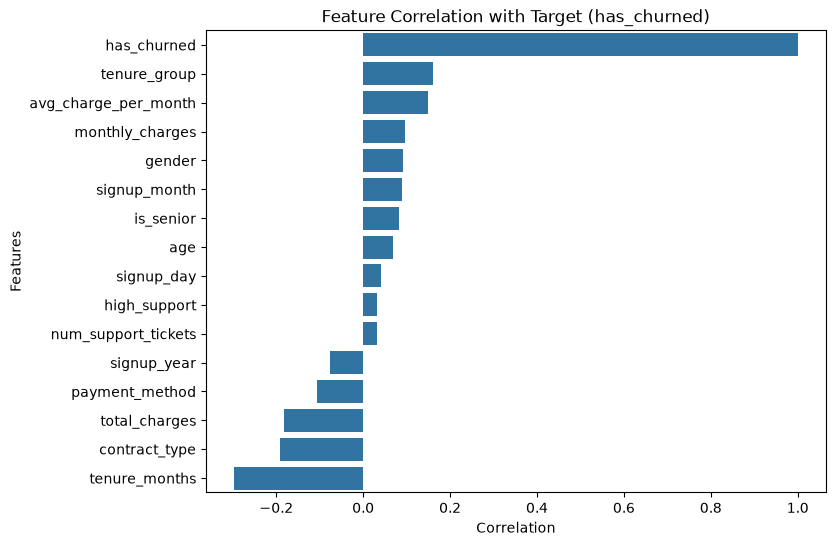

In [168]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation of each feature with the target
target_corr = df_model.corr(numeric_only=True)["has_churned"].sort_values(ascending=False)

print(target_corr)

plt.figure(figsize=(8,6))
sns.barplot(x=target_corr.values, y=target_corr.index)
plt.title("Feature Correlation with Target (has_churned)")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()

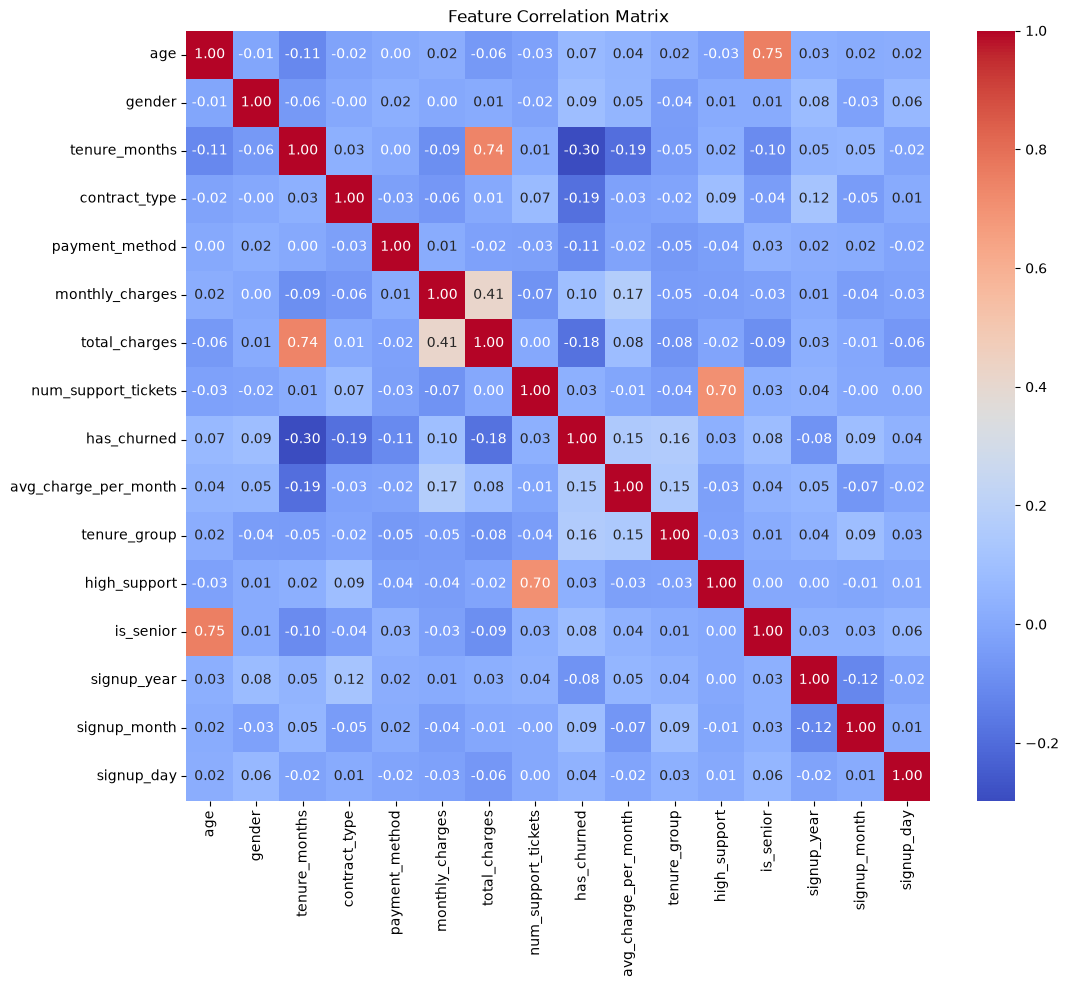

In [169]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df_model.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
# We are now checking for Overfitting (Logistic Regression)
from sklearn.metrics import accuracy_score

train_pred_log = log_model.predict(X_train_scaled)
test_pred_log = log_model.predict(X_test_scaled)

print("Training Accuracy :", accuracy_score(y_train, train_pred_log))
print("Testing Accuracy  :", accuracy_score(y_test, test_pred_log))

Training Accuracy : 0.7678571428571429
Testing Accuracy  : 0.7738095238095238


In [171]:
# # We are now checking for Overfitting (Random Forest)
train_pred_rf = rf_model.predict(X_train)
test_pred_rf = rf_model.predict(X_test)

print("Training Accuracy :", accuracy_score(y_train, train_pred_rf))
print("Testing Accuracy  :", accuracy_score(y_test, test_pred_rf))

Training Accuracy : 1.0
Testing Accuracy  : 0.7023809523809523


In [172]:
import os
import joblib

# 1. Create the 'model' directory if it doesn't exist
os.makedirs("model", exist_ok=True)

# 2. Save the model
joblib.dump(model, "model/churn_model.pkl")


['model/churn_model.pkl']